# How The El Niño Southern Oscillation Impacts Average Winter Temperature

## Analyzed With xmACIS2Py

***xmACIS2Py (C) Eric J. Drewitz 2025-2026***

*xmACIS2Py is an open-source Python package that directly interacts with the ACIS2 Web Services API
combined with a large suite of analysis tools to help analyze xmACIS2 data in Python.*

[xmACIS2Py Documentation](https://pypi.org/project/xmacis2py/)

[xmACIS2Py GitHub Repository](https://github.com/edrewitz/xmACIS2Py)

In this example, we will use xmACIS2Py and Pandas to analyze and plot how the El Niño Southern Oscillation impacts the average winter temperature across the Pacific Northwest.  

### Imports

In [1]:
# Imports Needed:
# - xmACIS2Py
# - Matplotlib
# - Pandas
# - NumPy
# - Cartopy
# - os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

# We need the following from xmACIS2Py:
# - analysis module (Consists of all xmACIS2Py Analysis Tools)
# - get_multi_station_acis_data client function - Downloads and returns a Pandas.DataFrame and/or CSV file of the ACIS2 Data.
# - multi_station_meta client function - Downloads and returns a Pandas.DataFrame and/or CSV file of the ACIS2 Meta-Data.
from xmacis2py import(
    analysis,
    get_multi_station_acis_data,
    multi_station_meta
)

### Downloading Our Data

In [2]:
# List of ASOS Stations across Washington, Oregon and Idaho

stations = [
    # --- Washington ---
    "KALW","KBFI","KBLI","KCLM","KDEW","KELN","KEPH","KFHR","KFCT","KFRD",
    "KGEG","KHQM","KKLS","KLSN","KLTJ","KMLP","KNUW","KOLM","KOMK","KORS",
    "KOTX","KPAE","KPSC","KPWT","KRNT","KSEA","KSHN","KSMP","KSPB","KSFF",
    "KTCM","KTIW","KUIL","KALW","KPUW","KELW","KGEG",

    # --- Oregon ---
    "KAST","KBKE","KBNO","KCVO","KEUG","KBDN","KHIO","KHRI","KLGD","KLKV",
    "KLMT","KMEH","KMMV","KMWA","KONP","KOTH","KPDX","KRBG","KRDM","KSLE",
    "KSPB","KTMK","KTTD","KUAO","KBDY","K4S2","KONO","K3S8",

    # --- Idaho ---
    "KBOI","KBYI","KCOE","KIDA","KJER","KLWS","KMAN","KMLD","KMYL","KPDT",
    "KPIH","KRXE","KSUN","KTWF","KLLJ","KSMN"
]


In [3]:
# Using xmACIS2Py to retrieve all the available data in the period between 1981-01-01 and 2025-12-31
get_multi_station_acis_data(stations,
                          start_date='1981-01-01',
                          end_date='2025-12-31',
                           to_csv=True,
                           return_pandas_df=False)

KALW Data Saved: XMACIS2 DATA/KALW.csv
KBFI Data Saved: XMACIS2 DATA/KBFI.csv
KBLI Data Saved: XMACIS2 DATA/KBLI.csv
KCLM Data Saved: XMACIS2 DATA/KCLM.csv
KDEW Data Saved: XMACIS2 DATA/KDEW.csv
KELN Data Saved: XMACIS2 DATA/KELN.csv
KEPH Data Saved: XMACIS2 DATA/KEPH.csv
KFHR Data Saved: XMACIS2 DATA/KFHR.csv
KFCT not found in database. Skipping...
KFRD not found in database. Skipping...
KGEG Data Saved: XMACIS2 DATA/KGEG.csv
KHQM Data Saved: XMACIS2 DATA/KHQM.csv
KKLS Data Saved: XMACIS2 DATA/KKLS.csv
KLSN not found in database. Skipping...
KLTJ not found in database. Skipping...
KMLP Data Saved: XMACIS2 DATA/KMLP.csv
KNUW Data Saved: XMACIS2 DATA/KNUW.csv
KOLM Data Saved: XMACIS2 DATA/KOLM.csv
KOMK Data Saved: XMACIS2 DATA/KOMK.csv
KORS not found in database. Skipping...
KOTX Data Saved: XMACIS2 DATA/KOTX.csv
KPAE Data Saved: XMACIS2 DATA/KPAE.csv
KPSC Data Saved: XMACIS2 DATA/KPSC.csv
KPWT Data Saved: XMACIS2 DATA/KPWT.csv
KRNT Data Saved: XMACIS2 DATA/KRNT.csv
KSEA Data Saved: XMA

In [4]:
# We are now going to extract all the station IDs for the stations that have data.
# The filename is the station ID so we need to extract that and remove the .csv file extension

stations_downloaded = []
for file in os.listdir(f"XMACIS2 DATA"):
    filename = os.path.basename(f"XMACIS2 DATA/{file}")
    filename = f"{filename[0:4]}"
    stations_downloaded.append(filename)

In [5]:
# We need the meta data for each station
# We need the latitude and longitude from this meta data

multi_station_meta(stations_downloaded,
                   to_csv=True,
                   return_pandas_df=False)

KALW.csv saved to XMACIS2 META
KAST.csv saved to XMACIS2 META
KBFI.csv saved to XMACIS2 META
KBKE.csv saved to XMACIS2 META
KBLI.csv saved to XMACIS2 META
KBNO.csv saved to XMACIS2 META
KBOI.csv saved to XMACIS2 META
KBYI.csv saved to XMACIS2 META
KCLM.csv saved to XMACIS2 META
KCOE.csv saved to XMACIS2 META
KCVO.csv saved to XMACIS2 META
KDEW.csv saved to XMACIS2 META
KELN.csv saved to XMACIS2 META
KEPH.csv saved to XMACIS2 META
KEUG.csv saved to XMACIS2 META
KFHR.csv saved to XMACIS2 META
KGEG.csv saved to XMACIS2 META
KHIO.csv saved to XMACIS2 META
KHQM.csv saved to XMACIS2 META
KHRI.csv saved to XMACIS2 META
KIDA.csv saved to XMACIS2 META
KJER.csv saved to XMACIS2 META
KKLS.csv saved to XMACIS2 META
KLGD.csv saved to XMACIS2 META
KLKV.csv saved to XMACIS2 META
KLLJ.csv saved to XMACIS2 META
KLMT.csv saved to XMACIS2 META
KLWS.csv saved to XMACIS2 META
KMEH.csv saved to XMACIS2 META
KMLD.csv saved to XMACIS2 META
KMLP.csv saved to XMACIS2 META
KMMV.csv saved to XMACIS2 META
KMYL.csv

### Organzing Our Meta-Data

Here, we will organize our meta-data into one Pandas.DataFrame by doing the following:

1) Use `pd.read_csv()` to create a Pandas.DataFrame for all CSV files in the XMACIS META Folder
2) Use `pd.concat()` to combine the list of Pandas.DataFrames into one Pandas.DataFrame

In [6]:
meta_data_list = []
for file in os.listdir(f"XMACIS2 META"):
    meta = pd.read_csv(f"XMACIS2 META/{file}")
    meta_data_list.append(meta)

meta = pd.concat(meta_data_list, ignore_index=True)

In [7]:
# Rename column "station" to "Station ID"
meta = meta.rename(columns={"station":"Station ID"})

In [8]:
# Meta-Data (Pandas.DataFrame)
meta

,Station ID,Station Name,Station Elevation (ft),State,Latitude,Longitude
0,ALW,WALLA WALLA REGIONAL AP,1170.0,WA,46.09456,-118.28572
1,AST,ASTORIA AIRPORT (PORT OF),11.0,OR,46.15694,-123.88326
2,BFI,SEATTLE BOEING FIELD,25.0,WA,47.54554,-122.31475
3,BKE,BAKER CITY AIRPORT,3363.0,OR,44.84301,-117.80987
4,BLI,BELLINGHAM INTL AP,150.0,WA,48.79910,-122.54069
...,...,...,...,...,...,...
60,KTIW,TACOMA NARROWS AP,290.0,WA,47.26744,-122.57623
61,TTD,PORTLAND TROUTDALE AP,25.0,OR,45.55098,-122.40984
62,KTWF,TWIN FALLS SUN VALLEY REGIONAL AP,4166.0,ID,42.47849,-114.47744
63,3S2,AURORA STATE AP,196.0,OR,45.24656,-122.77095


### Calculating Daily Climatological Normals

In this next section, we will calculate the daily normals for the entire period for each station.

In [9]:
for station, station_id in zip(stations_downloaded, meta['Station ID']):
    analysis.calculate_daily_normals(station_id,
                                     input_path=f"XMACIS2 DATA/{station}.csv",
                                     to_csv=True,
                                     return_pandas_df=False)

### Calculating Daily Departures From Normal "Daily Anomalies"

In this next section, we will calculate the daily departures from normal for each day in the period of record.

In [10]:
for station, station_id in zip(stations_downloaded, meta['Station ID']):
    analysis.calculate_daily_departures(station_id,
                                        ['Average Temperature'],
                                        raw_data_input_path=f"XMACIS2 DATA/{station}.csv",
                                        normals_input_path=f"XMACIS2 DAILY NORMALS/{station_id}.csv",
                                        to_csv=True,
                                        return_pandas_df=False)


### Choosing Our Analogs

In this next section, we will choose our Analogs for the Top 5 El Niño and Top 5 La Niña winter (DJF) periods since 1981.

***Oceanic Niño Index (NOAA)***


<img src="https://github.com/edrewitz/xmACIS2Py-Jupyter-Lab-Tutorials/blob/main/diagrams/oni%20index.png?raw=true" width="400" height="300">

***We will Filter Analog Years for the DJF period for the top 5 El Nino Years and top 5 La Nina Years***

***Top 5 El Nino Years (DJF)***: 1) 2016 = 2.6, 2) 1983 = 2.2, 3) 1998 = 2.2, 4) 2024 = 1.9, 5) 1992 = 1.7.

***Top 5 La Nina Years (DJF)***: 1) 1989 = -1.7, 2) 2000 = -1.7, 3) 2008 = -1.6, 4) 1999 = -1.5, 5) 2011 = -1.3. 

### Filtering Analogs

Here, we filter our El Niño and La Niña Analogs

In [11]:
for station in meta['Station ID']:
    # El Niño
    analysis.filter_analog_years(station,
                                 [(2015, 12), (2016, 1), (2016, 2),
                                 (1982, 12), (1983, 1), (1983, 2),
                                 (1997, 12), (1998, 1), (1998, 2),
                                 (2023, 12), (2024, 1), (2024, 2),
                                 (1991, 12), (1992, 1), (1992, 2)],
                                 input_path=f"XMACIS2 DAILY DEPARTURES/{station}.csv",
                                 to_csv=True,
                                 output_path=f"XMACIS2 ANALOGS/El Nino",
                                 return_pandas_df=False)



    # La Niña
    analysis.filter_analog_years(station,
                                 [(1988, 12), (1989, 1), (1989, 2),
                                 (1999, 12), (2000, 1), (2000, 2),
                                 (2007, 12), (2008, 1), (2008, 2),
                                 (1998, 12), (1999, 1), (1999, 2),
                                 (2010, 12), (2011, 1), (2011, 2)],
                                 input_path=f"XMACIS2 DAILY DEPARTURES/{station}.csv",
                                 to_csv=True,
                                 output_path=f"XMACIS2 ANALOGS/La Nina",
                                 return_pandas_df=False)



### Calculate Weighted Mean Anomalies

***El Nino Years Weights***: 2 for 2016; 1 for 1983; 1 for 1998; 1 for 2024; 1.5 for 1992. 

***La Nina Years Weights***: 2 for 1989; 1 for 2000; 1 for 2008; 1 for 1999; 1.5 for 2011. 

In [12]:
try:
    os.makedirs(f"El Nino Means")
except Exception as e:
    pass

try:
    os.makedirs(f"La Nina Means")
except Exception as e:
    pass

for station in meta['Station ID']:
    nino = pd.read_csv(f"XMACIS2 ANALOGS/EL NINO/{station}.csv")
    nino['Station'] = station

    nino['El Nino Temps Mean'] = analysis.analog_weighted_mean(nino, 
                                                 'Average Temperature_anom',
                                                 [2, 1, 1, 1, 1.5])

    nino.to_csv(f"El Nino Means/{station}.csv")

for station in meta['Station ID']:
    nina = pd.read_csv(f"XMACIS2 ANALOGS/LA NINA/{station}.csv")
    nina['Station'] = station

    nina['La Nina Temps Mean'] = analysis.analog_weighted_mean(nina, 
                                                 'Average Temperature_anom',
                                                 [2, 1, 1, 1, 1.5])

    nina.to_csv(f"La Nina Means/{station}.csv")
    

### Merge Pandas.DataFrames (Meta-Data & Anomalies)

Here, we will create a new Pandas.DataFrame that has the following:

1) Station ID
2) Latitude
3) Longitude
4) Anomaly

In [13]:
nino_anoms = []
for station in meta['Station ID']:
    df = pd.read_csv(f"El Nino Means/{station}.csv")
    nino_anom = df['El Nino Temps Mean'][0]
    nino_anoms.append(nino_anom)

el_nino = pd.DataFrame({
    "Station ID": meta['Station ID'],
    "anomaly": nino_anoms
})

In [14]:
nina_anoms = []
for station in meta['Station ID']:
    df = pd.read_csv(f"La Nina Means/{station}.csv")
    nina_anom = df['La Nina Temps Mean'][0]
    nina_anoms.append(nina_anom)

la_nina = pd.DataFrame({
    "Station ID": meta['Station ID'],
    "anomaly": nina_anoms
})

In [15]:
el_nino

,Station ID,anomaly
0,ALW,4.567791
1,AST,2.921263
2,BFI,NaN
3,BKE,4.614230
4,BLI,3.015782
...,...,...
60,KTIW,NaN
61,TTD,2.924270
62,KTWF,NaN
63,3S2,2.256167


In [16]:
la_nina

,Station ID,anomaly
0,ALW,-1.876056
1,AST,-1.815156
2,BFI,0.261764
3,BKE,-3.852179
4,BLI,-1.702826
...,...,...
60,KTIW,NaN
61,TTD,-1.435715
62,KTWF,NaN
63,3S2,-0.329053


In [17]:
el_nino = el_nino.merge(
    meta[["Station ID", "Latitude", "Longitude"]],
    on="Station ID",
    how="left"
)

In [18]:
el_nino = el_nino.dropna()

In [19]:
el_nino

,Station ID,anomaly,Latitude,Longitude
0,ALW,4.567791,46.09456,-118.28572
1,AST,2.921263,46.15694,-123.88326
3,BKE,4.614230,44.84301,-117.80987
4,BLI,3.015782,48.79910,-122.54069
5,BNO,2.819421,43.59486,-118.95788
6,BOI,3.435903,43.56705,-116.24062
7,BYI,2.713197,42.54525,-113.76860
13,EPH,3.085562,47.30777,-119.51551
14,EUG,2.108097,44.13311,-123.21563
16,GEG,3.550620,47.62168,-117.52796


In [20]:
la_nina = la_nina.merge(
    meta[["Station ID", "Latitude", "Longitude"]],
    on="Station ID",
    how="left"
)

In [21]:
la_nina = la_nina.dropna()

In [22]:
la_nina

,Station ID,anomaly,Latitude,Longitude
0,ALW,-1.876056,46.09456,-118.28572
1,AST,-1.815156,46.15694,-123.88326
2,BFI,0.261764,47.54554,-122.31475
3,BKE,-3.852179,44.84301,-117.80987
4,BLI,-1.702826,48.79910,-122.54069
5,BNO,-6.676382,43.59486,-118.95788
6,BOI,-1.429184,43.56705,-116.24062
7,BYI,-0.404245,42.54525,-113.76860
11,DEW,-0.571596,47.97416,-117.42921
13,EPH,-0.313174,47.30777,-119.51551


### Plot Our Data

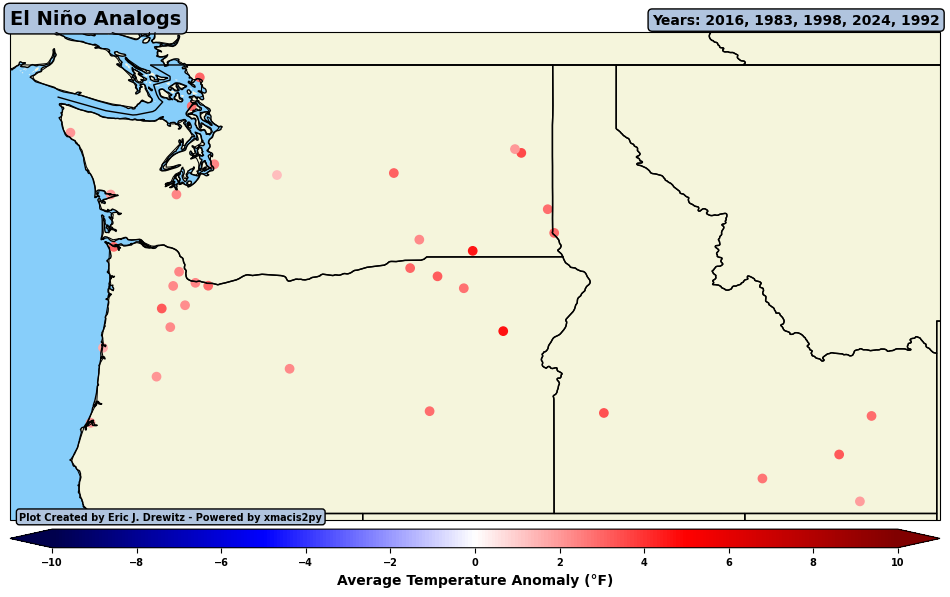

In [23]:
fig = plt.figure(figsize=(12,12))
box = dict(boxstyle='round', facecolor='lightsteelblue')
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
# Set our bounds and data coordinate reference system
ax.set_extent([-125.5, -111, 41.9, 49.5], ccrs.PlateCarree())

# Add coastlines for the outline of the coasts
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.75, zorder=9)

# Add our country borders
ax.add_feature(cfeature.BORDERS, linestyle='-', zorder=2)
ax.add_feature(cfeature.STATES, linestyle='-', zorder=2)
ax.add_feature(cfeature.LAND, facecolor='beige', zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor='lightskyblue', zorder=1)
ax.set_title(f"El Niño Analogs", fontsize=14, fontweight='bold', loc='left', bbox=box)
ax.set_title(f"Years: 2016, 1983, 1998, 2024, 1992", fontsize=10, fontweight='bold', loc='right', bbox=box)
ax.text(0.01, 0, f"Plot Created by Eric J. Drewitz - Powered by xmacis2py", fontsize=7, zorder=10, fontweight='bold', transform=ax.transAxes, bbox=box)
sc = ax.scatter(el_nino['Longitude'], el_nino['Latitude'], c=el_nino['anomaly'], cmap='seismic',
                norm=mcolors.Normalize(vmin=-10, vmax=10, clip=True))
cbar = fig.colorbar(sc, ax=ax, extend='both', location='bottom', pad=0.01, aspect=50)
cbar.set_ticks(np.arange(-10, 12, 2))
cbar.set_label("Average Temperature Anomaly (°F)", fontweight='bold', fontsize=10)

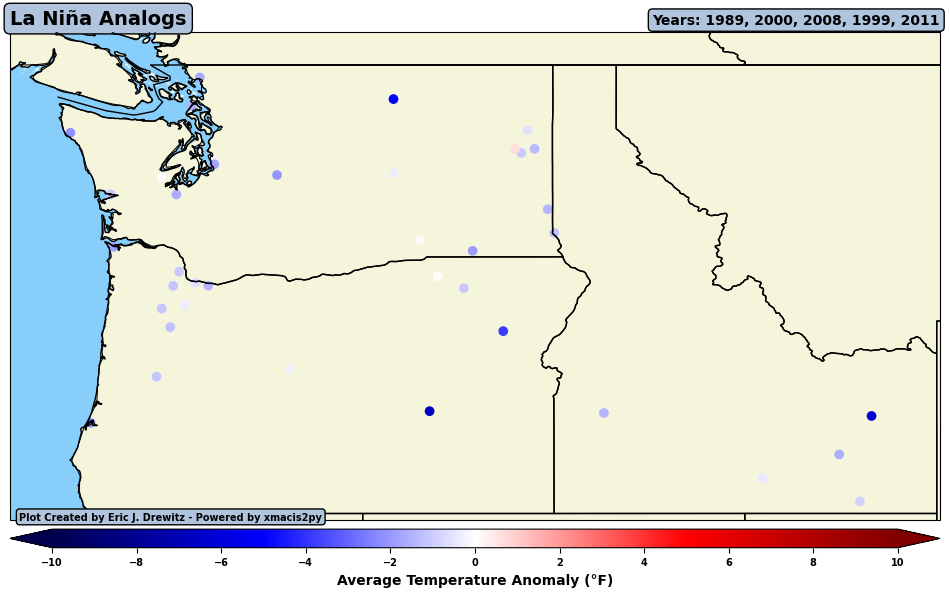

In [24]:
fig = plt.figure(figsize=(12,12))
box = dict(boxstyle='round', facecolor='lightsteelblue')
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
# Set our bounds and data coordinate reference system
ax.set_extent([-125.5, -111, 41.9, 49.5], ccrs.PlateCarree())

# Add coastlines for the outline of the coasts
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.75, zorder=9)

# Add our country borders
ax.add_feature(cfeature.BORDERS, linestyle='-', zorder=2)
ax.add_feature(cfeature.STATES, linestyle='-', zorder=2)
ax.add_feature(cfeature.LAND, facecolor='beige', zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor='lightskyblue', zorder=1)
ax.set_title(f"La Niña Analogs", fontsize=14, fontweight='bold', loc='left', bbox=box)
ax.set_title(f"Years: 1989, 2000, 2008, 1999, 2011", fontsize=10, fontweight='bold', loc='right', bbox=box)
ax.text(0.01, 0, f"Plot Created by Eric J. Drewitz - Powered by xmacis2py", fontsize=7, zorder=10, fontweight='bold', transform=ax.transAxes, bbox=box)
sc = ax.scatter(la_nina['Longitude'], la_nina['Latitude'], c=la_nina['anomaly'], cmap='seismic',
                norm=mcolors.Normalize(vmin=-10, vmax=10, clip=True))
cbar = fig.colorbar(sc, ax=ax, extend='both', location='bottom', pad=0.01, aspect=50)
cbar.set_ticks(np.arange(-10, 12, 2))
cbar.set_label("Average Temperature Anomaly (°F)", fontweight='bold', fontsize=10)